In [2]:
import pandas as pd
import numpy as np


# Importando a base de dados
df = pd.read_csv('https://raw.githubusercontent.com/PedroNotaroberto/Dados_tcc/refs/heads/main/Planilha%20Demandas_Judiciais_2020_e_2021.csv', sep=';')


# Renomeando colunas para facilitar o manuseio dos dados
df.rename(columns={ 
    'Identif Item Compra' : 'Identif_Item_Compra', 
    'Cod UResp Compra' : 'Cod_UResp_Compra', 
    'UF UResp Compra' : 'UF_UResp_Compra',
    'Esfera UResp Compra' : 'Esfera_UResp_Compra', 
    'Unnamed: 4' : 'Item_Compra_Descricao', 
    'Desc Compl Item Compra' : 'Desc_Compl_Item_Compra',
    'Modalidade Compra' : 'Modalidade_Compra', 
    'Inciso Disp Legal' : 'Inciso_Disp_Legal', 
    'Justif Dispensa/Inexig' : 'Justif_Dispensa_Inexig',
    'Forma Realização' : 'Forma_Realização', 
    'CPF/CNPJ Fornecedor' : 'CPF_CNPJ_Fornecedor', 
    'Nome Fornecedor' : 'Nome_Fornecedor',
    'Porte Empresa Fornec' : 'Porte_Empresa_Fornec', 
    'Fabric Material Compra' : 'Fabric_Material_Compra',
    'Ano Resultado Compra' : 'Ano_Resultado_Compra', 
    'Dia Resultado Compra' : 'Dia_Resultado_Compra',
    'Mês Final Vigen Ata SRP' : 'Mês_Final_Vigen_Ata_SRP', 
    'Unidade Fornecimento' : 'Unidade_Fornecimento', 
    'Qtde Comprada Item' : 'Qtde_Comprada_Item',
    'Valor Unitário Homologado' : 'Valor_Unitário_Homologado', 
    'Valor Total Homologado' : 'Valor_Total_Homologado'
}, inplace=True)

In [3]:
# Passando a coluna de valor total
# para o tipo correto para análise

df['Valor_Total_Homologado'] = df['Valor_Total_Homologado'].str.replace('.', '', regex=False)
df['Valor_Total_Homologado'] = df['Valor_Total_Homologado'].str.replace(',', '.', regex=False)
df['Valor_Total_Homologado'] = df['Valor_Total_Homologado'].astype('Float64')


df['Qtde_Comprada_Item'] = df['Qtde_Comprada_Item'].str.replace('.', '', regex=False)
df['Qtde_Comprada_Item'] = df['Qtde_Comprada_Item'].str.replace(',', '.', regex=False)
df['Qtde_Comprada_Item'] = df['Qtde_Comprada_Item'].astype('Float64')

df['Valor_Unitário_Homologado'] = df['Valor_Unitário_Homologado'].str.replace('.', '', regex=False)
df['Valor_Unitário_Homologado'] = df['Valor_Unitário_Homologado'].str.replace(',', '.', regex=False)
df['Valor_Unitário_Homologado'] = df['Valor_Unitário_Homologado'].astype('Float64')

In [4]:
# Selecionando somente as linahs que possuem a palavra "judicial" na justificativa
df_jud = df.query(
    "Justif_Dispensa_Inexig.str.contains('judicial', case=False, na=False)")

# Selecionando somente os anos de 2017 a 2021
df_jud_anos = df_jud.query(
    "Ano_Resultado_Compra >= 2017 and Ano_Resultado_Compra <= 2021")

# Removendo colunas que não serão utilizadas na análise
df_jud_anos_menor = df_jud_anos.drop([
    'Esfera_UResp_Compra', 'Desc_Compl_Item_Compra', 
    'Modalidade_Compra', 'Unidade_Fornecimento', 'Identif_Item_Compra', 
    'Cod_UResp_Compra', 'UF_UResp_Compra', 'Inciso_Disp_Legal', 
    'Forma_Realização', 'CPF_CNPJ_Fornecedor', 'Porte_Empresa_Fornec', 
    'Fabric_Material_Compra',  'Dia_Resultado_Compra', 'Mês_Final_Vigen_Ata_SRP'
    ], axis=1)

In [5]:
df_jud_anos_menor = df_jud_anos_menor.drop(['Nome_Fornecedor'], axis=1)

In [6]:
df_jud_anos_menor.head()

,Item_Compra_Descricao,Justif_Dispensa_Inexig,Ano_Resultado_Compra,Qtde_Comprada_Item,Valor_Unitário_Homologado,Valor_Total_Homologado
1455,"INSULINA, ORIGEM:GLARGINA, DOSAGEM:100UI/ML, ...",Justificativa: Trata-se de Ação Judicial,2017,40.0,76.94,3077.6
1456,"MERCAPTAMINA, COMPOSIÇÃO:SAL BITARTARATO, CON...",Justificativa: Trata-se de Ação Judicial.,2018,1950.0,71.478,139382.1
1457,"MERCAPTAMINA, CONCENTRAÇÃO:25 MG",Justificativa: Trata-se de Ação Judicial.,2018,150.0,121.5126,18226.89
1458,"VISMODEGIBE, CONCENTRAÇÃO:150 MG",Justificativa: Trata-se de Ação Judicial,2019,196.0,609.49,119460.04
1459,"TRASTUZUMABE, COMPOSIÇÃO:ENTANSINA, CONCENTRA...",Justificativa: Trata-se de Ação Judicial,2019,10.0,8403.96,84039.6


In [7]:
# Filtrando a coluna de descrição do item de compra 
# Mantendo apenas o nome do medicamento, 
# removendo informações adicionais como dosagem e forma farmacêutica
df_jud_anos_menor['Item_Compra_Descricao'] = df_jud_anos_menor[
    'Item_Compra_Descricao'].str.split(',').str[0].str.strip()

# Filtrando o horizonte temporal para os anos de 2017 a 2021
years_of_interest = [2017, 2018, 2019, 2020, 2021]
df_filtered = df_jud_anos_menor[
    df_jud_anos_menor['Ano_Resultado_Compra'].isin(years_of_interest)]

# Excluíndo "VACINA" e "MONITOR MULTIPARÂMETRO"
items_to_exclude = ["VACINA", "MONITOR MULTIPARÂMETRO"]
df_filtered = df_filtered[
    ~df_filtered['Item_Compra_Descricao'].isin(items_to_exclude)]

# Agrupando pelo nome do medicamento e somando o valor total homologado para cada um
df_cost_per_drug = df_filtered.groupby('Item_Compra_Descricao')[
    'Valor_Total_Homologado'].sum().reset_index()

# Filtrando os resultados em ordem decrescente de custo total
df_top_25 = df_cost_per_drug.sort_values(
    by='Valor_Total_Homologado', ascending=False).reset_index().drop(columns=['index'])

# 5. Display the top 26 drugs that incurred the most cost
print("Top 25 princípios ativos por custo (2017-2021):")
print(df_top_25.head(25))

Top 25 princípios ativos por custo (2017-2021):
    Item_Compra_Descricao  Valor_Total_Homologado
0             ECULIZUMABE           1858423070.77
1               ATALURENO            664750850.26
2              GALSULFASE            364616482.48
3           ALFAGALSIDASE            237543572.14
4         ELOSULFASE ALFA            232267852.11
5             NUSINERSENA             200835520.6
6             IDURSULFASE             192821879.4
7            METRELEPTINA            169494472.38
8         BETA-AGALSIDASE            100220242.22
9      ALFA-ALGLICOSIDASE              92459383.3
10             SEBELIPASE             53159793.23
11              CLOZAPINA              43442374.8
12              IVACAFTOR             42353999.61
13           MERCAPTAMINA              33299665.7
14             LOMITAPIDA             32151897.77
15             ETEPLIRSEN              26053775.7
16             LARONIDASE              23999659.2
17  BRENTUXIMABE VEDOTINA             21222986.85
18

In [8]:
# filtra base, exclui itens e mantém apenas os anos de interesse
years_of_interest = [2017, 2018, 2019, 2020, 2021]
items_to_exclude = ["VACINA", "MONITOR MULTIPARÂMETRO"]

df_filtered = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(years_of_interest)) & 
    (~df_jud_anos_menor['Item_Compra_Descricao'].isin(items_to_exclude))
]

# encontrando o top 25 medicamentos por custo total
df_total_cost = df_filtered.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum()
top_25_drugs = df_total_cost.nlargest(25).index

# filtrando para incluir somente os top 25 medicamentos
df_top_25 = df_filtered[df_filtered[
    'Item_Compra_Descricao'].isin(top_25_drugs)] # type: ignore

# tabela pivot para mostrar o valor total homologado 
# por ano para cada um dos top 25 medicamentos
df_yearly_breakdown = df_top_25.pivot_table(
    index='Item_Compra_Descricao', 
    columns='Ano_Resultado_Compra', 
    values='Valor_Total_Homologado', 
    aggfunc='sum',
    fill_value=0
)

# adicionando uma coluna de total para cada medicamento
df_yearly_breakdown['Total'] = df_yearly_breakdown.sum(axis=1)

# ordenando os medicamentos pelo total em ordem decrescente
df_yearly_breakdown = df_yearly_breakdown.sort_values(by='Total', ascending=False)

# mostrando o resultado final
print("Top 25 - Compras por ano e total:")
print(df_yearly_breakdown)

Top 25 - Compras por ano e total:
Ano_Resultado_Compra           2017          2018          2019          2020  \
Item_Compra_Descricao                                                           
ECULIZUMABE            267111498.55  447156839.74  448846922.03  220640259.57   
ATALURENO              119981430.92  156757192.64           0.0   142352168.1   
GALSULFASE             158802361.94  153214936.78   52599183.76           0.0   
ALFAGALSIDASE           90633087.37   98535767.73   48374717.04           0.0   
ELOSULFASE ALFA         91085221.56  104878635.01   36303995.54           0.0   
NUSINERSENA                     0.0  115860815.49   84974705.11           0.0   
IDURSULFASE             58263241.22  130544231.68           0.0    2101238.05   
METRELEPTINA            29642083.24   17554704.06   12615675.88   36465101.37   
BETA-AGALSIDASE         49448569.66   50273966.06      497706.5           0.0   
ALFA-ALGLICOSIDASE      29966089.04   42547643.66           0.0    19945650

In [9]:
'''
# Export the final pivoted dataframe to an Excel file
df_yearly_breakdown.to_excel("top_25_medicamentos_custos.xlsx", sheet_name="Custos 2017-2021")
'''

'\n# Export the final pivoted dataframe to an Excel file\ndf_yearly_breakdown.to_excel("top_25_medicamentos_custos.xlsx", sheet_name="Custos 2017-2021")\n'

--- TABELA DE CONCENTRAÇÃO DE GASTOS (TOP 25) ---
Item_Compra_Descricao          Total  Participacao_Percentual  Percentual_Acumulado
          ECULIZUMABE  1858423070.77                41.530762             41.530762
            ATALURENO   664750850.26                14.855395             56.386157
           GALSULFASE   364616482.48                 8.148199             64.534356
        ALFAGALSIDASE   237543572.14                 5.308461             69.842816
      ELOSULFASE ALFA   232267852.11                 5.190562             75.033379
          NUSINERSENA    200835520.6                 4.488134             79.521513
          IDURSULFASE    192821879.4                 4.309051             83.830564
         METRELEPTINA   169494472.38                 3.787746              87.61831
      BETA-AGALSIDASE   100220242.22                 2.239653             89.857963
   ALFA-ALGLICOSIDASE     92459383.3                 2.066219             91.924182
           SEBELIPASE    5

/tmp/ipykernel_807/3021754067.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_807/3021754067.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")


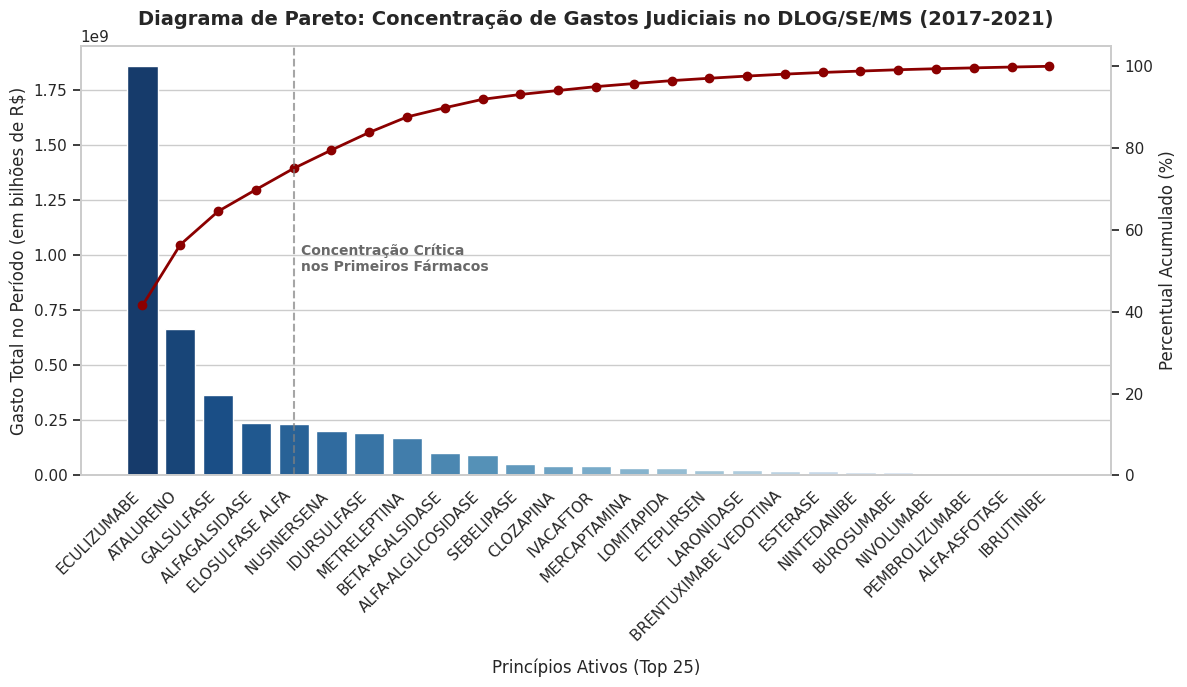

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configuração estética dos gráficos para o padrão acadêmico
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "font.family": "sans-serif"})

# 1. Preparação dos dados a partir do df_yearly_breakdown criado no Cap 3
# Isolando a coluna 'Total' e ordenando de forma decrescente
df_pareto = df_yearly_breakdown[["Total"]].copy()
df_pareto = df_pareto.sort_values(by="Total", ascending=False).reset_index()

# 2. Cálculos estatísticos de concentração
gasto_total_recorte = df_pareto["Total"].sum()
df_pareto["Participacao_Percentual"] = (
    df_pareto["Total"] / gasto_total_recorte
) * 100
df_pareto["Percentual_Acumulado"] = df_pareto["Participacao_Percentual"].cumsum()

# Exibição da tabela estruturada de concentração no console
print("--- TABELA DE CONCENTRAÇÃO DE GASTOS (TOP 25) ---")
print(
    df_pareto[
        [
            "Item_Compra_Descricao",
            "Total",
            "Participacao_Percentual",
            "Percentual_Acumulado",
        ]
    ].to_string(index=False)
)

# 3. Construção do Gráfico de Pareto (Barras + Linha Acumulada)
fig, ax1 = plt.subplots(figsize=(12, 7))

# Gráfico de barras para o gasto individual por medicamento
sns.barplot(
    data=df_pareto,
    x="Item_Compra_Descricao",
    y="Total",
    ax=ax1,
    palette="Blues_r",
)
ax1.set_title(
    "Diagrama de Pareto: Concentração de Gastos Judiciais no DLOG/SE/MS (2017-2021)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
ax1.set_xlabel("Princípios Ativos (Top 25)", fontsize=12, labelpad=10)
ax1.set_ylabel("Gasto Total no Período (em bilhões de R$)", fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# Criação do segundo eixo y para a linha de percentual acumulado
ax2 = ax1.twinx()
ax2.plot(
    df_pareto["Item_Compra_Descricao"],
    df_pareto["Percentual_Acumulado"],
    color="darkred",
    marker="o",
    linewidth=2,
    label="% Acumulado",
)
ax2.set_ylabel("Percentual Acumulado (%)", fontsize=12)
ax2.set_ylim(0, 105)
ax2.grid(False)  # Remove linhas de grade duplicadas

# Adicionando linha de corte vertical ou horizontal para destacar a assimetria (Ex: corte no 5º medicamento)
ax2.axvline(x=4, color="gray", linestyle="--", alpha=0.7)
ax2.text(
    4.2,
    50,
    "Concentração Crítica\nnos Primeiros Fármacos",
    color="dimgray",
    fontsize=10,
    fontweight="semibold",
)

plt.tight_layout()
plt.savefig("diagrama_pareto_gastos_dlog.png", dpi=300)
plt.show()

Yearly Contribution Table:
                        Total_Geral   Total_Top_25  %_Contribuicao_Top_25
Ano_Resultado_Compra                                                     
2017                   979001580.59   954339469.52              97.480892
2018                  1397458950.18  1359186777.62              97.261303
2019                   747125574.22   720949582.45               96.49644
2020                   592497748.99   548477792.81              92.570443
2021                   930761456.95    891857311.1              95.820181


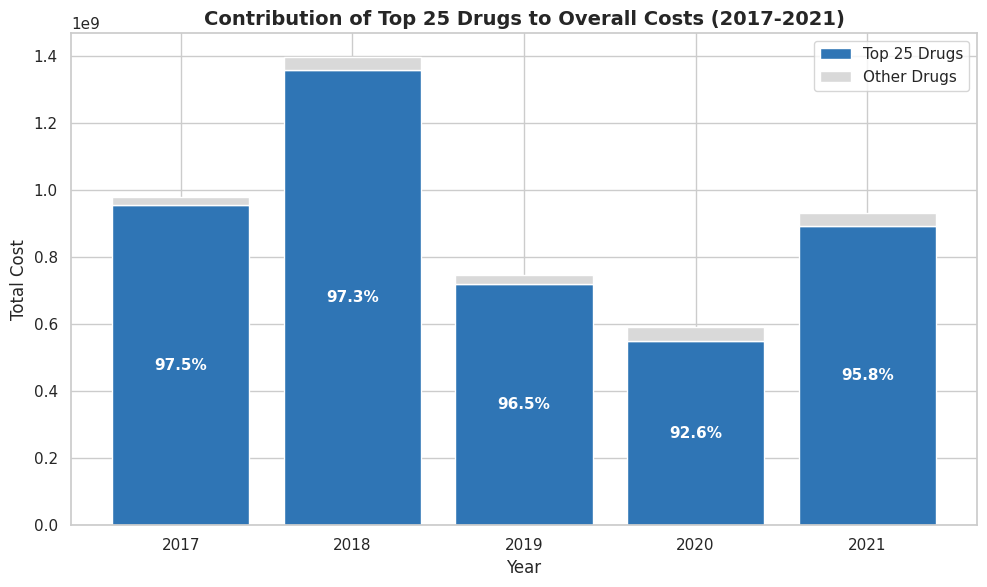

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Base filtering (Years & Exclusions) - Assuming you haven't done this already in the current cell
years_of_interest = [2017, 2018, 2019, 2020, 2021]
items_to_exclude = ["VACINA", "MONITOR MULTIPARÂMETRO"]

df_filtered = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(years_of_interest)) & 
    (~df_jud_anos_menor['Item_Compra_Descricao'].isin(items_to_exclude))
]

# 2. Find the Top 25 overall drugs
df_total_cost = df_filtered.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum()
top_25_drugs = df_total_cost.nlargest(25).index

# 3. Create a DataFrame for ONLY the top 25 drugs
df_top_25 = df_filtered[df_filtered['Item_Compra_Descricao'].isin(top_25_drugs)]

# --- NEW LOGIC FOR COMPARISON ---

# 4. Calculate total costs per year (All drugs vs Top 25)
yearly_total_all = df_filtered.groupby('Ano_Resultado_Compra')['Valor_Total_Homologado'].sum()
yearly_total_top25 = df_top_25.groupby('Ano_Resultado_Compra')['Valor_Total_Homologado'].sum()

# 5. Build a Comparison DataFrame
df_comparison = pd.DataFrame({
    'Total_Geral': yearly_total_all,
    'Total_Top_25': yearly_total_top25
})

# Calculate the cost of "Other Drugs" and the percentage of the Top 25
df_comparison['Outros_Medicamentos'] = df_comparison['Total_Geral'] - df_comparison['Total_Top_25']
df_comparison['%_Contribuicao_Top_25'] = (df_comparison['Total_Top_25'] / df_comparison['Total_Geral']) * 100

print("Yearly Contribution Table:")
print(df_comparison[['Total_Geral', 'Total_Top_25', '%_Contribuicao_Top_25']])

# 6. Plot the Graph (Stacked Bar Chart)
plt.figure(figsize=(10, 6))

# Plot Top 25 first (bottom layer), then "Others" on top
plt.bar(df_comparison.index, df_comparison['Total_Top_25'], label='Top 25 Drugs', color='#2F75B5')
plt.bar(df_comparison.index, df_comparison['Outros_Medicamentos'], bottom=df_comparison['Total_Top_25'], label='Other Drugs', color='#D9D9D9')

# Styling the graph
plt.title('Contribution of Top 25 Drugs to Overall Costs (2017-2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Cost', fontsize=12)
plt.xticks(df_comparison.index)
plt.legend()

# Add the percentage text right in the middle of the blue bars
for ano in df_comparison.index:
    perc = df_comparison.loc[ano, '%_Contribuicao_Top_25']
    y_pos = df_comparison.loc[ano, 'Total_Top_25'] / 2  # Place text halfway up the bottom bar
    plt.text(ano, y_pos, f'{perc:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# 1. Base filtering (Years & Exclusions)
years_of_interest = [2017, 2018, 2019, 2020, 2021]


df_filtered = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(years_of_interest)) 
]

# 2. Find the Top 25 overall drugs
df_total_cost = df_filtered.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum()
top_25_drugs = df_total_cost.nlargest(25).index

# 3. Create a DataFrame for ONLY the top 25 drugs
df_top_25 = df_filtered[df_filtered['Item_Compra_Descricao'].isin(top_25_drugs)]

# 4. Calculate total costs AND unique counts per year
yearly_total_all = df_filtered.groupby('Ano_Resultado_Compra')['Valor_Total_Homologado'].sum()
yearly_total_top25 = df_top_25.groupby('Ano_Resultado_Compra')['Valor_Total_Homologado'].sum()

# ---> NEW: Calculate the total number of unique drugs purchased each year
yearly_unique_drugs = df_filtered.groupby('Ano_Resultado_Compra')['Item_Compra_Descricao'].nunique()

# 5. Build the final Comparison DataFrame
df_comparison = pd.DataFrame({
    'Qtd_Medicamentos_Unicos': yearly_unique_drugs,
    'Total_Geral': yearly_total_all,
    'Total_Top_25': yearly_total_top25
})

# Calculate the percentage contribution of the Top 25
df_comparison['%_Contribuicao_Top_25'] = (df_comparison['Total_Top_25'] / df_comparison['Total_Geral']) * 100

# Optional: Format the dataframe so the numbers are easier to read in the console
df_comparison_formatted = df_comparison.copy()
df_comparison_formatted['Total_Geral'] = df_comparison_formatted['Total_Geral'].map('R$ {:,.2f}'.format)
df_comparison_formatted['Total_Top_25'] = df_comparison_formatted['Total_Top_25'].map('R$ {:,.2f}'.format)
df_comparison_formatted['%_Contribuicao_Top_25'] = df_comparison_formatted['%_Contribuicao_Top_25'].map('{:.2f}%'.format)

print("Yearly Summary: Unique Drugs vs Cost Contribution")
print(df_comparison_formatted)

Yearly Summary: Unique Drugs vs Cost Contribution
                      Qtd_Medicamentos_Unicos          Total_Geral  \
Ano_Resultado_Compra                                                 
2017                                      329    R$ 979,001,580.59   
2018                                      231  R$ 1,397,458,950.18   
2019                                      203    R$ 747,125,574.22   
2020                                      179  R$ 1,535,297,748.99   
2021                                      140  R$ 1,015,308,926.95   

                             Total_Top_25 %_Contribuicao_Top_25  
Ano_Resultado_Compra                                             
2017                    R$ 953,856,938.12                97.43%  
2018                  R$ 1,356,520,555.52                97.07%  
2019                    R$ 718,267,655.95                96.14%  
2020                  R$ 1,487,071,340.92                96.86%  
2021                    R$ 969,185,148.80                95.46%

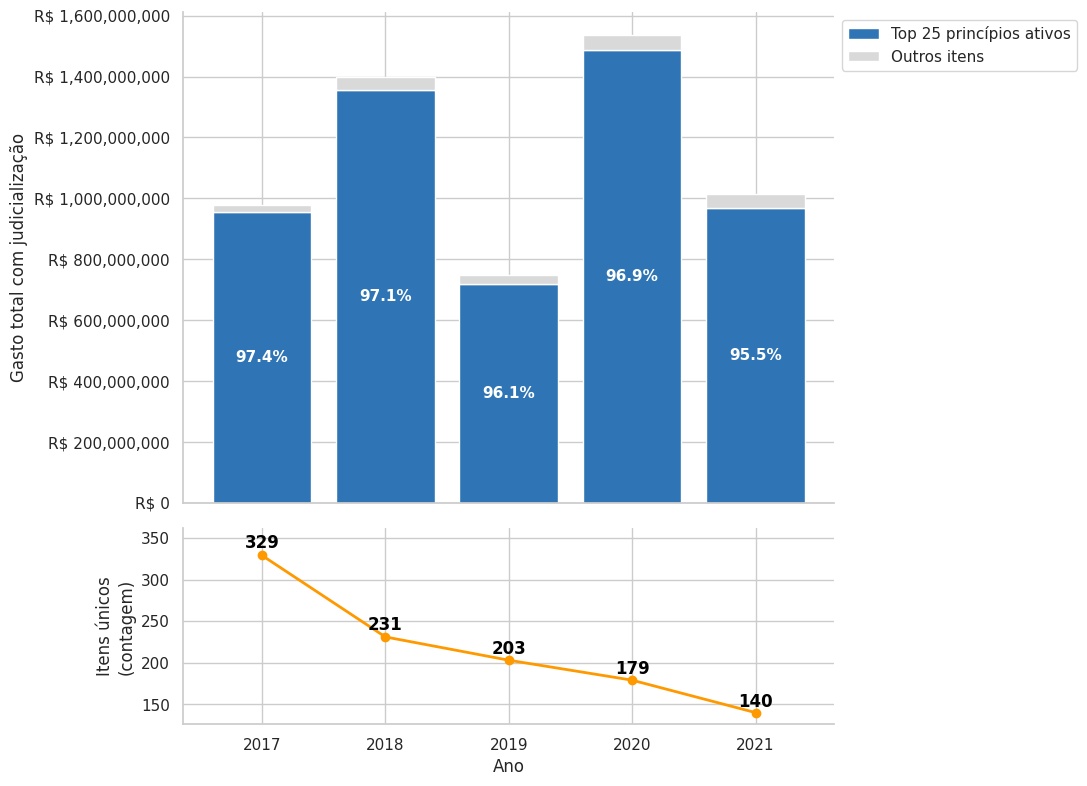

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Base filtering
years_of_interest = [2017, 2018, 2019, 2020, 2021]


df_filtered = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(years_of_interest)) 
]

# 2. Find the Top 25 overall drugs
df_total_cost = df_filtered.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum()
top_25_drugs = df_total_cost.nlargest(25).index

# 3. Create a DataFrame for ONLY the top 25 drugs
df_top_25 = df_filtered[df_filtered['Item_Compra_Descricao'].isin(top_25_drugs)]

# 4. Calculate total costs AND unique counts per year
yearly_total_all = df_filtered.groupby('Ano_Resultado_Compra')['Valor_Total_Homologado'].sum()
yearly_total_top25 = df_top_25.groupby('Ano_Resultado_Compra')['Valor_Total_Homologado'].sum()
yearly_unique_drugs = df_filtered.groupby('Ano_Resultado_Compra')['Item_Compra_Descricao'].nunique()

# 5. Build the Comparison DataFrame
df_comparison = pd.DataFrame({
    'Qtd_Medicamentos_Unicos': yearly_unique_drugs,
    'Total_Geral': yearly_total_all,
    'Total_Top_25': yearly_total_top25
})

df_comparison['Outros_Medicamentos'] = df_comparison['Total_Geral'] - df_comparison['Total_Top_25']
df_comparison['%_Contribuicao_Top_25'] = (df_comparison['Total_Top_25'] / df_comparison['Total_Geral']) * 100

# --- NEW: Plotting Subplots ---
# Create 2 rows, 1 column. sharex=True locks the x-axis together. 
# gridspec_kw makes the top chart larger than the bottom one.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

# --- Top Subplot: Costs ---
ax1.bar(df_comparison.index, df_comparison['Total_Top_25'], label='Top 25 princípios ativos', color='#2F75B5')
ax1.bar(df_comparison.index, df_comparison['Outros_Medicamentos'], bottom=df_comparison['Total_Top_25'], label='Outros itens', color='#D9D9D9')

ax1.set_ylabel('Gasto total com judicialização', fontsize=12)
# ax1.set_title('Cost Contribution & Unique Drugs Purchased (2017-2021)', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1)) 

# Add percentage text to the top chart
for ano in df_comparison.index:
    perc = df_comparison.loc[ano, '%_Contribuicao_Top_25']
    y_pos = df_comparison.loc[ano, 'Total_Top_25'] / 2
    ax1.text(ano, y_pos, f'{perc:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# Clean up top chart borders
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Bottom Subplot: Unique Drugs ---
ax2.plot(df_comparison.index, df_comparison['Qtd_Medicamentos_Unicos'], color='#FF9900', marker='o', linestyle='-', linewidth=2, markersize=6)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Itens únicos\n(contagem)', fontsize=12)
ax2.set_xticks(df_comparison.index)
ax2.set_ylim(df_comparison['Qtd_Medicamentos_Unicos'].min() * 0.9, df_comparison['Qtd_Medicamentos_Unicos'].max() * 1.1)

# Add exact count labels above the dots on the bottom chart
for ano in df_comparison.index:
    count = df_comparison.loc[ano, 'Qtd_Medicamentos_Unicos']
    ax2.text(ano, count * 1.015, f'{count}', ha='center', va='bottom', color="#020202", fontweight='bold', fontsize=12)

# Clean up bottom chart borders
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

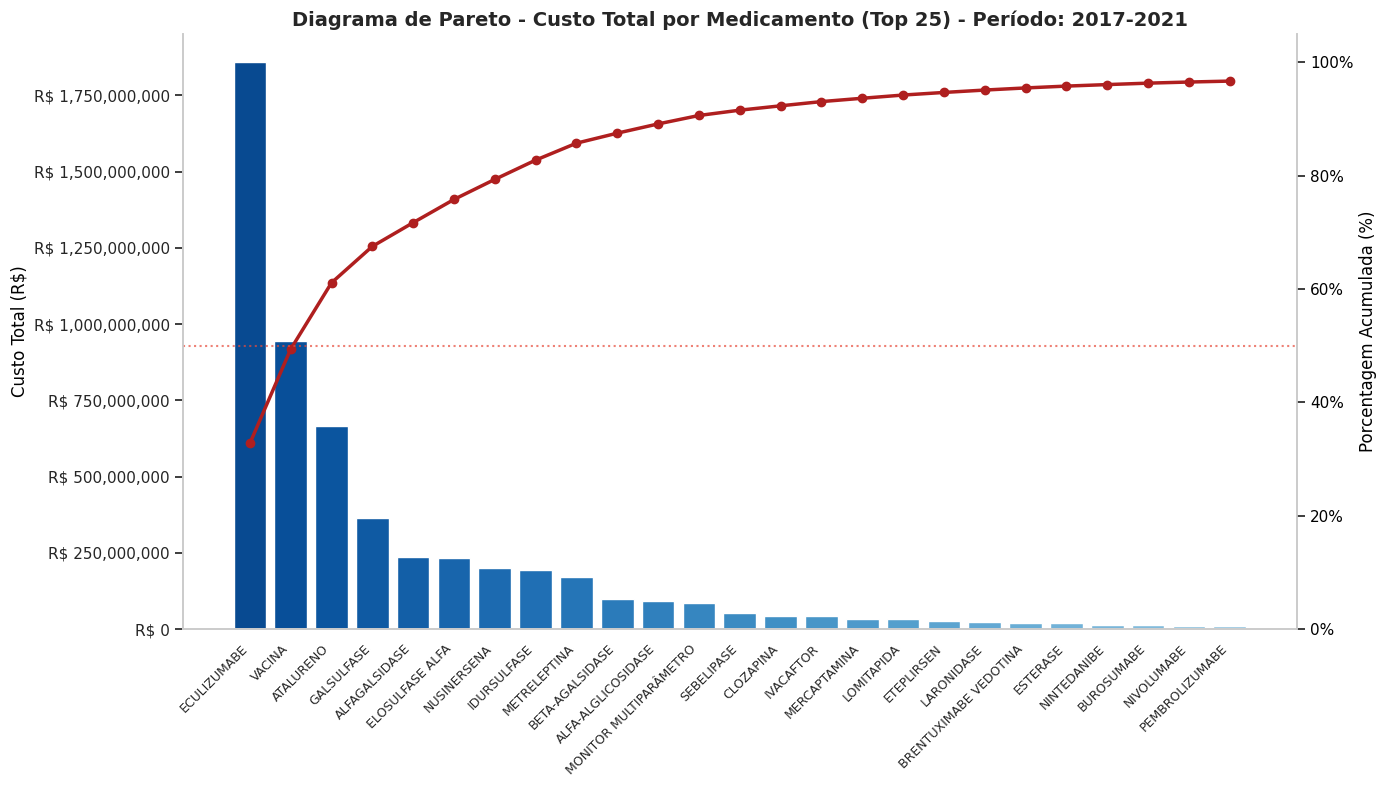

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Filtro base (Anos e Exclusões)
anos_interesse = [2017, 2018, 2019, 2020, 2021]


df_filtrado = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(anos_interesse)) 
]

# 2. Preparar os dados para o Pareto
df_pareto = df_filtrado.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum().reset_index()
df_pareto = df_pareto.sort_values(by='Valor_Total_Homologado', ascending=False)

total_geral = df_pareto['Valor_Total_Homologado'].sum()
df_pareto['Custo_Acumulado'] = df_pareto['Valor_Total_Homologado'].cumsum()
df_pareto['Porcentagem_Acumulada'] = (df_pareto['Custo_Acumulado'] / total_geral) * 100

# Selecionar o Top 25
df_pareto_top = df_pareto.head(25)

# 3. Encontrar o índice onde a porcentagem ultrapassa 50%
porcentagens = df_pareto_top['Porcentagem_Acumulada'].values
idx_50 = np.argmax(porcentagens > 50) 

# 4. Criar o Degradê (Gradient) de cores para as barras
# Usando a paleta 'Blues', indo de escuro (0.9) para claro (0.4)
cores_degrade = plt.cm.Blues(np.linspace(0.9, 0.4, len(df_pareto_top)))

# 5. Plotar o Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(14, 8))

# Barras com degradê
ax1.bar(df_pareto_top['Item_Compra_Descricao'], df_pareto_top['Valor_Total_Homologado'], color=cores_degrade)
ax1.set_ylabel('Custo Total (R$)', fontsize=12, color='black')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}"))
plt.xticks(rotation=45, ha='right', fontsize=9)

# Linha de Porcentagem
ax2 = ax1.twinx()
ax2.plot(df_pareto_top['Item_Compra_Descricao'], df_pareto_top['Porcentagem_Acumulada'], 
         color="#AF1F1F", marker='o', linewidth=2.5, markersize=6)
ax2.set_ylabel('Porcentagem Acumulada (%)', fontsize=12, color="#000000")
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.tick_params(axis='y', labelcolor="#000000")
ax2.set_ylim(0, 105) 

# --- LINHAS DE CORTE DOS 50% ---


# Linha Horizontal (opcional, para formar a "cruz" na marca de 50%)
ax2.axhline(y=50, color='#E74C3C', linestyle=':', linewidth=1.5, alpha=0.7)



# Desativar grids
ax1.grid(False)
ax2.grid(False)

plt.title('Diagrama de Pareto - Custo Total por Medicamento (Top 25) - Período: 2017-2021', fontsize=14, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

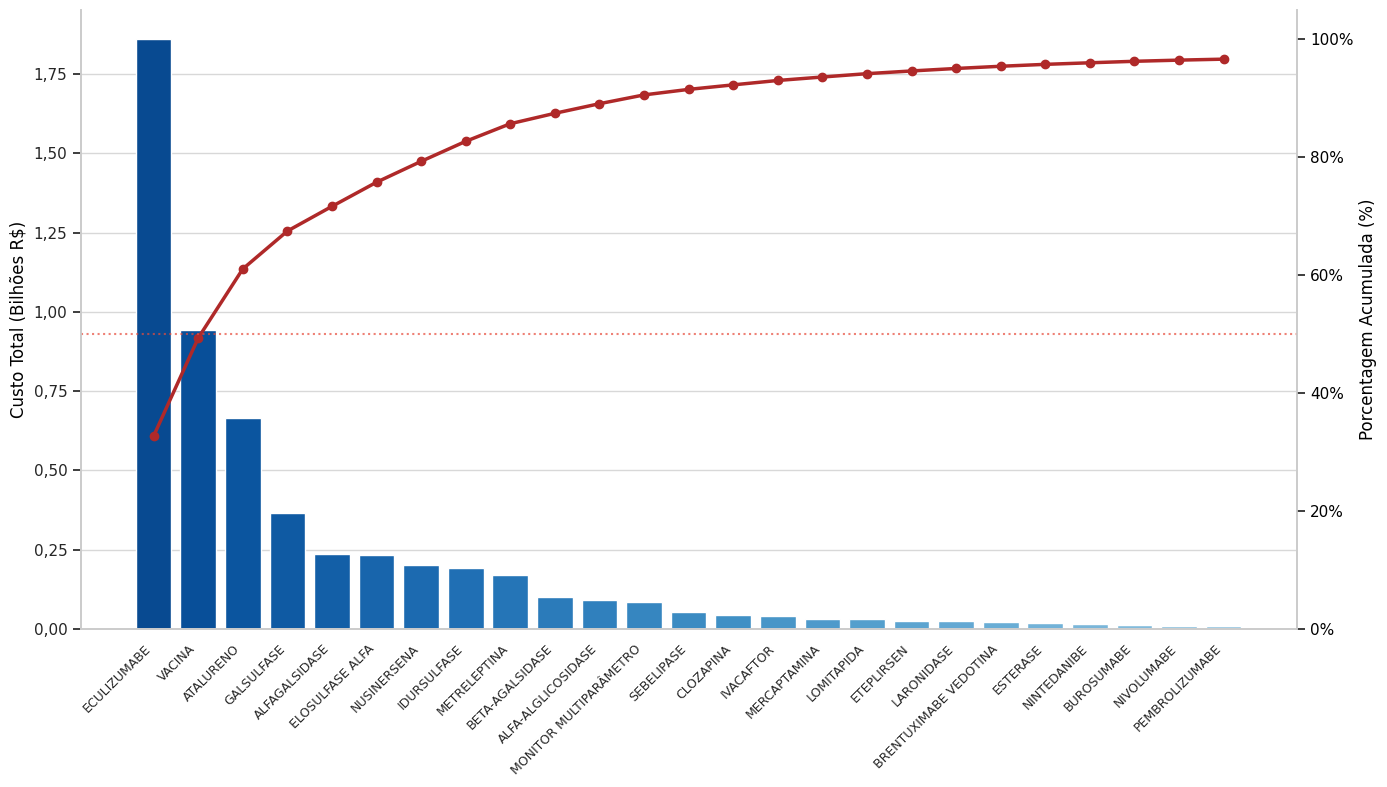

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# 1. Filtro base (Anos e Exclusões)
anos_interesse = [2017, 2018, 2019, 2020, 2021]


df_filtrado = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(anos_interesse)) 
]

# 2. Preparar os dados para o Pareto
df_pareto = df_filtrado.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum().reset_index()
df_pareto = df_pareto.sort_values(by='Valor_Total_Homologado', ascending=False)

total_geral = df_pareto['Valor_Total_Homologado'].sum()
df_pareto['Custo_Acumulado'] = df_pareto['Valor_Total_Homologado'].cumsum()
df_pareto['Porcentagem_Acumulada'] = (df_pareto['Custo_Acumulado'] / total_geral) * 100

# Selecionar o Top 25
df_pareto_top = df_pareto.head(25)

# 3. Encontrar o índice onde a porcentagem ultrapassa 50%
porcentagens = df_pareto_top['Porcentagem_Acumulada'].values
idx_50 = np.argmax(porcentagens > 50) 

# 4. Criar o Degradê (Gradient) de cores
cores_degrade = plt.cm.Blues(np.linspace(0.9, 0.4, len(df_pareto_top)))

# 5. Plotar o Gráfico de Pareto
fig, ax1 = plt.subplots(figsize=(14, 8))

ax1.bar(df_pareto_top['Item_Compra_Descricao'], df_pareto_top['Valor_Total_Homologado'], color=cores_degrade)

# --- NOVA LÓGICA DE FORMATAÇÃO (BILHÕES) ---
# Alterando o label do Eixo Y
ax1.set_ylabel('Custo Total (Bilhões R$)', fontsize=12, color='black')

# Função para dividir por 1 bilhão e formatar com 2 casas decimais (padrão BR com vírgula)
def formata_bilhoes(x, pos):
    return f"{x / 1e9:.2f}".replace('.', ',')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(formata_bilhoes))
# -------------------------------------------

plt.xticks(rotation=45, ha='right', fontsize=9)

# Linha de Porcentagem
ax2 = ax1.twinx()
ax2.plot(df_pareto_top['Item_Compra_Descricao'], df_pareto_top['Porcentagem_Acumulada'], 
         color="#AF2929", marker='o', linewidth=2.5, markersize=6)
ax2.set_ylabel('Porcentagem Acumulada (%)', fontsize=12, color="#000000")
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.tick_params(axis='y', labelcolor="#000000")
ax2.set_ylim(0, 105) 

# Linhas de Corte
# ax1.axvline(x=idx_50, color='#E74C3C', linestyle='--', linewidth=2, zorder=0)
ax2.axhline(y=50, color='#E74C3C', linestyle=':', linewidth=1.5, alpha=0.7)
# ax2.plot(idx_50, porcentagens[idx_50], marker='o', markersize=12, color='white', markeredgecolor='#E74C3C', markeredgewidth=2, zorder=5)



# --- MODIFICAÇÃO DAS GRIDLINES ---
# Desativa explicitamente as linhas verticais (eixo X)
ax1.xaxis.grid(False)

# Ativa explicitamente apenas as linhas horizontais (eixo Y) do eixo principal
ax1.yaxis.grid(True, linestyle='-', alpha=0.3, color='gray', zorder=0)

# Garante que o eixo secundário não desenhe NENHUMA linha de grade extra
ax2.grid(False)
# ---------------------------------

# plt.title('Diagrama de Pareto - Custo Total por Medicamento (Top 25) - Período: 2017-2021', fontsize=14, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

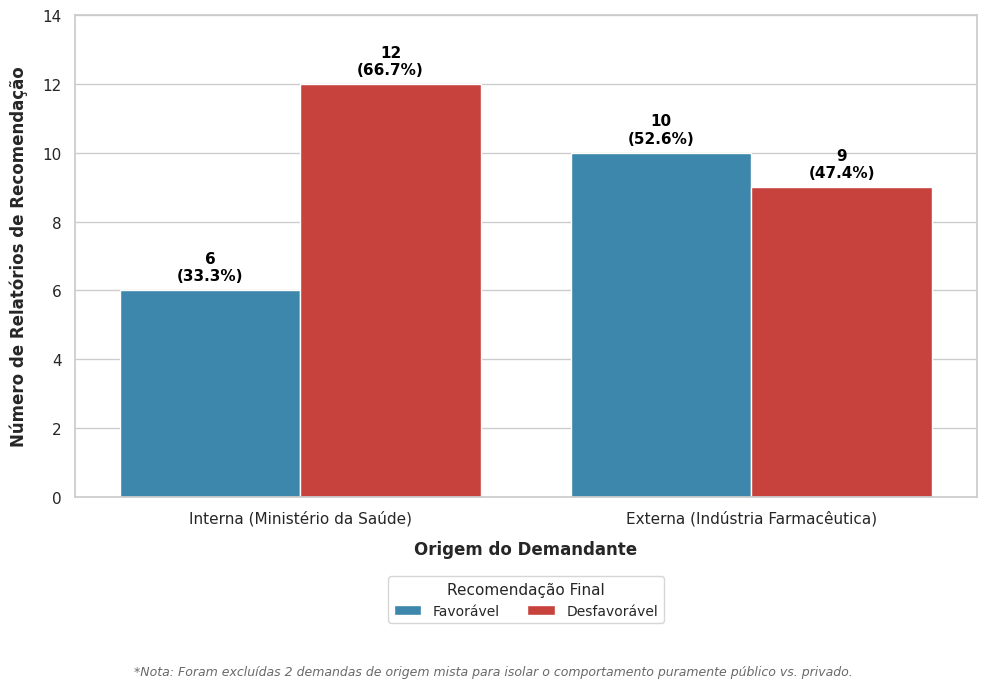

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configurações estéticas acadêmicas (padrão ABNT)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "font.family": "sans-serif"})

# 1. Criação do DataFrame com os dados consolidados do Capítulo 3
dados_conitec = {
    'Origem_Demanda': ['Interna (Ministério da Saúde)', 'Interna (Ministério da Saúde)', 
                       'Externa (Indústria Farmacêutica)', 'Externa (Indústria Farmacêutica)'],
    'Desfecho_Final': ['Favorável', 'Desfavorável', 'Favorável', 'Desfavorável'],
    'Quantidade': [6, 12, 10, 9] # Nossos números exatos (18 internos, 19 externos)
}

df_origem = pd.DataFrame(dados_conitec)

# 2. Construção do Gráfico de Barras Agrupadas
fig, ax = plt.subplots(figsize=(10, 6.5))

# Usando uma paleta de cores sóbria (Azul para Favorável, Vermelho escuro para Desfavorável)
cores = ["#2b8cbe", "#de2d26"]

barplot = sns.barplot(
    data=df_origem,
    x='Origem_Demanda',
    y='Quantidade',
    hue='Desfecho_Final',
    palette=cores,
    ax=ax
)

# 3. Adicionando os Rótulos de Dados (Percentuais) em cima das barras
# Isso é crucial para a banca bater o olho e ver os 33% vs 52%
totais_por_origem = {'Interna (Ministério da Saúde)': 18, 'Externa (Indústria Farmacêutica)': 19}

for p in ax.patches:
    altura = p.get_height()
    if altura > 0: # Evita tentar anotar barras vazias (NaN)
        # Identifica a qual categoria a barra pertence baseado na posição x
        x_pos = p.get_x() + p.get_width() / 2
        categoria = 'Interna (Ministério da Saúde)' if x_pos < 0.5 else 'Externa (Indústria Farmacêutica)'
        
        # Calcula a porcentagem
        percentual = (altura / totais_por_origem[categoria]) * 100
        
        # Insere o texto em cima da barra
        ax.annotate(f'{int(altura)}\n({percentual:.1f}%)', 
                    (x_pos, altura), 
                    ha='center', va='bottom',
                    xytext=(0, 5), textcoords='offset points',
                    fontweight='bold', fontsize=11, color='black')

# 4. Formatação e Títulos

ax.set_xlabel("Origem do Demandante", fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel("Número de Relatórios de Recomendação", fontsize=12, fontweight='bold', labelpad=10)

# Ajuste do limite Y para dar espaço aos rótulos acima das barras
ax.set_ylim(0, 14)

# Configuração da Legenda
ax.legend(title="Recomendação Final", title_fontsize='11', fontsize='10', 
          loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True)

# Inserindo uma nota metodológica no rodapé do gráfico
nota = "*Nota: Foram excluídas 2 demandas de origem mista para isolar o comportamento puramente público vs. privado."
fig.text(0.5, -0.05, nota, ha='center', fontsize=9, style='italic', color='dimgray')

plt.tight_layout()
plt.savefig("figura_w_assimetria_origem.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
import pandas as pd

# 1. Filtrar os anos de interesse e excluir itens indesejados (como vacinas e monitores)
anos_interesse = [2017, 2018, 2019, 2020, 2021]
itens_excluir = ["VACINA", "MONITOR MULTIPARÂMETRO"]

df_filtrado = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(anos_interesse)) &
    (~df_jud_anos_menor['Item_Compra_Descricao'].isin(itens_excluir))
]

# 2. Descobrir o Top 25 medicamentos com maior custo TOTAL no período
df_custo_total = df_filtrado.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum()
top_25_medicamentos = df_custo_total.nlargest(25).index

# 3. Filtrar o dataframe original para manter apenas as compras desses Top 25 medicamentos
df_top_25 = df_filtrado[df_filtrado['Item_Compra_Descricao'].isin(top_25_medicamentos)]

# 4. Criar a tabela dinâmica calculando a MÉDIA do valor unitário por ano
tabela_valor_unitario = df_top_25.pivot_table(
    index='Item_Compra_Descricao',        # Medicamentos nas linhas
    columns='Ano_Resultado_Compra',       # Anos nas colunas
    values='Valor_Unitário_Homologado',   # Coluna de onde extrair os valores
    aggfunc='mean'                        # Agregação: média (caso haja mais de uma compra no ano)
)

# 5. Reordenar a tabela para manter a ordem do Top 25 (do maior ofensor financeiro geral para o menor)
tabela_valor_unitario = tabela_valor_unitario.reindex(top_25_medicamentos)

# 6. Formatar os valores para exibição como moeda no padrão brasileiro (R$)
# (Se não houver compra em um ano específico, aparecerá um traço "-")
tabela_formatada = tabela_valor_unitario.applymap(
    lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') if pd.notnull(x) else "-"
)

# Exibir o resultado
print("Evolução do Valor Unitário Médio (2017-2021) - Top 25 Medicamentos:")
print(tabela_formatada)

Evolução do Valor Unitário Médio (2017-2021) - Top 25 Medicamentos:
Ano_Resultado_Compra           2017           2018           2019  \
Item_Compra_Descricao                                               
ECULIZUMABE            R$ 17.285,31   R$ 13.508,74   R$ 12.661,38   
ATALURENO               R$ 1.551,14    R$ 2.189,08              -   
GALSULFASE              R$ 5.339,17    R$ 5.535,68    R$ 4.677,56   
ALFAGALSIDASE           R$ 3.935,20    R$ 4.129,99    R$ 4.381,96   
ELOSULFASE ALFA         R$ 2.859,04    R$ 3.134,85    R$ 2.878,29   
NUSINERSENA                       -  R$ 239.535,54  R$ 212.477,37   
IDURSULFASE             R$ 4.890,24    R$ 5.617,55              -   
METRELEPTINA            R$ 7.323,19   R$ 13.365,75   R$ 15.868,77   
BETA-AGALSIDASE         R$ 9.386,99    R$ 9.419,12    R$ 9.954,13   
ALFA-ALGLICOSIDASE      R$ 1.414,35    R$ 1.443,81              -   
SEBELIPASE             R$ 25.623,76   R$ 24.971,52   R$ 21.173,65   
CLOZAPINA                   R$ 2,75

/tmp/ipykernel_807/2341112205.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_formatada = tabela_valor_unitario.applymap(


In [18]:
# Exportar os números brutos (ideal para fazer fórmulas e gráficos no próprio Excel)
tabela_valor_unitario.to_excel("evolucao_valor_unitario.xlsx", sheet_name="Valor Unitario Medio")

In [19]:
import pandas as pd

# 1. Filtro base (Anos e Exclusões)
anos_interesse = [2017, 2018, 2019, 2020, 2021]
itens_excluir = ["VACINA", "MONITOR MULTIPARÂMETRO"]

df_filtrado = df_jud_anos_menor[
    (df_jud_anos_menor['Ano_Resultado_Compra'].isin(anos_interesse)) &
    (~df_jud_anos_menor['Item_Compra_Descricao'].isin(itens_excluir))
]

# 2. Descobrir o Top 25 medicamentos
df_custo_total = df_filtrado.groupby('Item_Compra_Descricao')['Valor_Total_Homologado'].sum()
top_25_medicamentos = df_custo_total.nlargest(25).index
df_top_25 = df_filtrado[df_filtrado['Item_Compra_Descricao'].isin(top_25_medicamentos)]

# 3. Criar a tabela dinâmica dupla (Valores e Quantidades)
tabela_mista = df_top_25.pivot_table(
    index='Item_Compra_Descricao',
    columns='Ano_Resultado_Compra',
    values=['Valor_Unitário_Homologado', 'Qtde_Comprada_Item'],
    aggfunc={
        'Valor_Unitário_Homologado': 'mean', # Tira a média dos preços unitários
        'Qtde_Comprada_Item': 'sum'          # Soma as quantidades compradas no ano
    }
)

# 4. Reorganizar as colunas
# O Pandas cria as colunas como: (Valor Médio, 2017), (Quantidade, 2017)...
# O swaplevel e o sort_index invertem isso para ficar agrupado por ano: 
# 2017 (Valor, Quantidade), 2018 (Valor, Quantidade)...
tabela_mista = tabela_mista.swaplevel(axis=1).sort_index(axis=1, level=0)

# Renomear as sub-colunas para ficarem mais elegantes no relatório
tabela_mista = tabela_mista.rename(columns={
    'Valor_Unitário_Homologado': 'Preço Médio Unit.',
    'Qtde_Comprada_Item': 'Qtd Comprada'
})

# 5. Voltar à ordem original do Top 25 ofensores
tabela_mista = tabela_mista.reindex(top_25_medicamentos)

# 6. Formatação (Opcional: para exibir bonito no console)
for col in tabela_mista.columns:
    if 'Preço Médio Unit.' in col: # Se for a coluna de dinheiro, formata como R$
        tabela_mista[col] = tabela_mista[col].apply(
            lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.') if pd.notnull(x) else "-"
        )
    else: # Se for a coluna de quantidade, formata como número inteiro com separador de milhar
        tabela_mista[col] = tabela_mista[col].apply(
            lambda x: f"{int(x):,}".replace(',', '.') if pd.notnull(x) else "-"
        )

# Exibir a tabela gerada
print("Evolução: Preço Médio vs. Quantidade Comprada (Top 25)")
print(tabela_mista)

# 7. Salvar em Excel
tabela_mista.to_excel("evolucao_valor_e_quantidade.xlsx", sheet_name="Preco vs Quantidade")

Evolução: Preço Médio vs. Quantidade Comprada (Top 25)
Ano_Resultado_Compra          2017                           2018  \
                      Qtd Comprada Preço Médio Unit. Qtd Comprada   
Item_Compra_Descricao                                               
ECULIZUMABE                 13.721      R$ 17.285,31       32.877   
ATALURENO                  117.270       R$ 1.551,14      130.590   
GALSULFASE                  29.669       R$ 5.339,17       27.092   
ALFAGALSIDASE               23.084       R$ 3.935,20       23.320   
ELOSULFASE ALFA             31.362       R$ 2.859,04       31.234   
NUSINERSENA                      -                 -          488   
IDURSULFASE                 10.907       R$ 4.890,24       21.984   
METRELEPTINA                 4.175       R$ 7.323,19        1.335   
BETA-AGALSIDASE              5.298       R$ 9.386,99        5.350   
ALFA-ALGLICOSIDASE          21.309       R$ 1.414,35       29.723   
SEBELIPASE                     267      R$ 25.62